In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from project.data_manager import DataManager

In [2]:
manager = DataManager()

In [3]:
flights = '../database/flights.csv'
wanted_cols = wanted_cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
    'DELAYED',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'WHEELS_OFF'
]

In [4]:
df = manager.create_flights_dataframe(delay_limit=15, csv_path=flights)

In [5]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0


In [6]:
df.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT             str
DESTINATION_AIRPORT        str
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
DELAYED                  int64
dtype: o

In [36]:
filtered_df = manager.create_df_sample(df=df, percentage=2, wanted_cols=wanted_cols)
#manager.show_stats(filtered_df)

hours_to_transform = [
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL',
    'DEPARTURE_TIME',
    'WHEELS_OFF'
]

mins_to_transform = [
    'TAXI_OUT',
    'DEPARTURE_DELAY',    
]

manager.hour_to_sec(df=filtered_df, cols=hours_to_transform)
manager.min_to_sec(df=filtered_df, cols=mins_to_transform)

filtered_df = filtered_df.drop('DEPARTURE_DELAY', axis=1)
filtered_df = filtered_df.drop('DEPARTURE_TIME', axis=1)
filtered_df = filtered_df.drop('TAXI_OUT', axis=1)
#filtered_df = filtered_df.drop('WHEELS_OFF', axis=1)

filtered_df = manager.create_aux_features(filtered_df=filtered_df)
[x_train, x_test, y_train, y_test] = manager.get_test_split(df=filtered_df, target='DELAYED')

filtered_df


,MONTH,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,SCHEDULED_ARRIVAL,DELAYED,WHEELS_OFF,PERIOD,SEASON,HOLIDAY
3335058,7,1,OO,CVG,MKE,58980,318,59880,0,60060.0,AFTERNOON,SUMMER,1
4857110,10,5,DL,13204,12953,66180,950,76080,0,67020.0,EVENING,FALL,0
4454180,10,1,WN,13796,14747,42600,672,49500,0,43500.0,MORNING,FALL,0
5132772,11,2,DL,ATL,SAV,47100,214,50820,0,47640.0,AFTERNOON,FALL,1
4075015,9,5,OO,GEG,SEA,21600,224,25200,0,22380.0,MORNING,FALL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282928,3,2,OO,IAH,CVG,56100,871,67920,1,58560.0,AFTERNOON,SPRING,0
3349673,7,2,NK,ORD,ATL,49320,606,60120,0,50460.0,AFTERNOON,SUMMER,1
5350571,12,2,DL,DEN,DTW,58500,1123,75660,0,58800.0,AFTERNOON,WINTER,1
1566498,4,5,UA,IAD,IAH,79260,1190,720,0,79680.0,EVENING,SPRING,0


In [ ]:
#codigo feito por ia tentando debugar
# ratio = total_negativos / total_positivos
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Instanciando o SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicando APENAS nos dados de TREINO 
# (Nunca aplique no teste, senão você avaliará o modelo em dados sintéticos!)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Antes do SMOTE: {Counter(y_train)}")
print(f"Depois do SMOTE: {Counter(y_train_smote)}")

ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 4. Treinamento do XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=None,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist' # Acelera o treino em datasets grandes
)

model_xgb.fit(x_train, y_train)

# 5. Predições e Avaliação
y_pred_xgb = model_xgb.predict(x_test)
y_proba_xgb = model_xgb.predict_proba(x_test)[:, 1]
print('\n\n')
print("--- Relatório de Classificação: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
print('\n\n')
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    recall_1 = classification_report(y_test, y_pred_t, output_dict=True)['1']['recall']
    precision_1 = classification_report(y_test, y_pred_t, output_dict=True)['1']['precision']
    print(f"Threshold {t:.1f} | Recall: {recall_1:.2f} | Precisão: {precision_1:.2f}")

Antes do SMOTE: Counter({0: 65196, 1: 14800})
Depois do SMOTE: Counter({0: 65196, 1: 65196})



--- Relatório de Classificação: XGBoost ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     27941
           1       0.94      0.68      0.79      6343

    accuracy                           0.93     34284
   macro avg       0.93      0.84      0.87     34284
weighted avg       0.93      0.93      0.93     34284

ROC-AUC Score: 0.9496

Matriz de Confusão:
[[27644   297]
 [ 2024  4319]]



Threshold 0.1 | Recall: 0.92 | Precisão: 0.55
Threshold 0.2 | Recall: 0.85 | Precisão: 0.76
Threshold 0.3 | Recall: 0.79 | Precisão: 0.85
Threshold 0.4 | Recall: 0.74 | Precisão: 0.90
Threshold 0.5 | Recall: 0.68 | Precisão: 0.94


In [24]:
# Inicializando o modelo
# n_jobs=-1 usa todos os núcleos do seu i7 para acelerar o treino
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=15, 
                                  random_state=42,
                                  class_weight='balanced', 
                                  n_jobs=-1)

# Treinando
model_rf.fit(x_train, y_train)

# Predições
y_pred = model_rf.predict(x_test)
y_proba = model_rf.predict_proba(x_test)[:, 1]

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de Confusão para entender Falsos Positivos e Falsos Negativos
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(conf_matrix)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.85      0.78      0.81     28508
           1       0.28      0.38      0.32      6407

    accuracy                           0.71     34915
   macro avg       0.56      0.58      0.57     34915
weighted avg       0.74      0.71      0.72     34915

ROC-AUC Score: 0.6372

Matriz de Confusão:
[[22247  6261]
 [ 3965  2442]]


C:\Users\Pedro\AppData\Local\Temp\ipykernel_12776\4062758199.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')


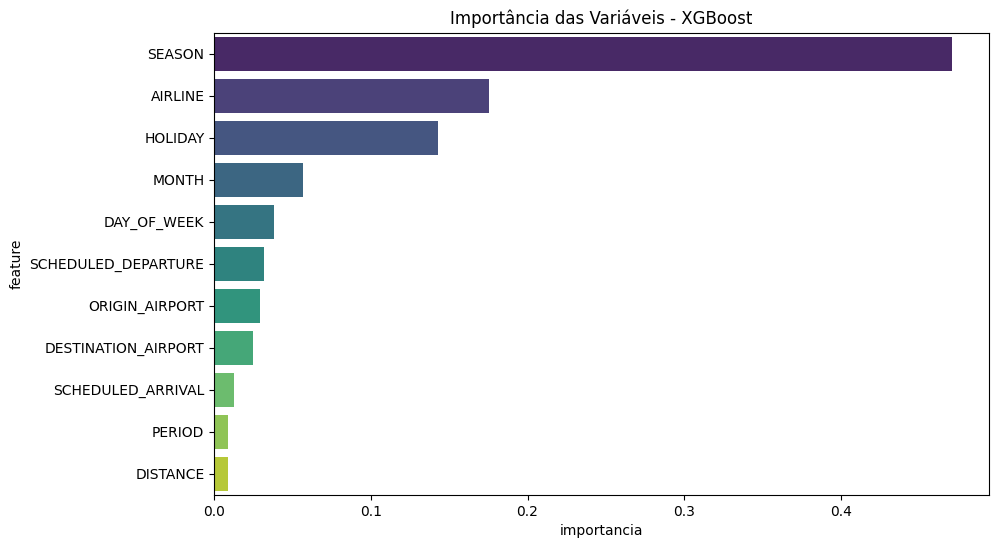

                feature  importancia
9                SEASON     0.471063
2               AIRLINE     0.175245
10              HOLIDAY     0.142804
0                 MONTH     0.056523
1           DAY_OF_WEEK     0.038070
5   SCHEDULED_DEPARTURE     0.032043
3        ORIGIN_AIRPORT     0.029180
4   DESTINATION_AIRPORT     0.024523
7     SCHEDULED_ARRIVAL     0.012969
8                PERIOD     0.009057
6              DISTANCE     0.008525


In [21]:
# Pegando as importâncias do modelo treinado
importancias = pd.DataFrame({
    'feature': x_train.columns,
    'importancia': model_xgb.feature_importances_
}).sort_values(by='importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')
plt.title('Importância das Variáveis - XGBoost')
plt.show()

print(importancias)